# Group 5 - Member 1: Global Feature Importance & SHAP Explainability

This notebook conducts comprehensive global model explainability for the selected final churn model (Tuned Logistic Regression).

### Key Objectives:
1. Inspect model weights and extract standardized coefficients.
2. Compute Odds Ratios ( = e^{\beta}$) and percentage multipliers for all features.
3. Perform exact Global SHAP analysis (mean absolute SHAP rankings and beeswarm plots).
4. Identify the strongest churn accelerators and protectors.
5. Explain model behavior and decision boundaries.

In [1]:
import os, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Setup paths
CURRENT_DIR = Path.cwd()
SRC_DIR = CURRENT_DIR.parent / "src" if CURRENT_DIR.name == "notebooks" else CURRENT_DIR / "src"
sys.path.insert(0, str(SRC_DIR))

from explainers import ChurnModelExplainer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

## 1. Load Data and Reconstruct Selected Model Pipeline

In [2]:
DATA_PATH = Path("../Feature Engineering & Statistical Analysis/outputs/customer_churn_feature_engineered.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("../../Feature Engineering & Statistical Analysis/outputs/customer_churn_feature_engineered.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("Feature Engineering & Statistical Analysis/outputs/customer_churn_feature_engineered.csv")

df = pd.read_csv(DATA_PATH)

CORE_FEATURES = [
    "Senior Citizen", "Partner", "Dependents", "Tenure Months", "Multiple Lines",
    "Internet Service", "Online Security", "Online Backup", "Device Protection",
    "Tech Support", "Streaming TV", "Streaming Movies", "Contract",
    "Paperless Billing", "Payment Method", "Monthly Charges", "Total Charges",
    "Fiber_Monthly_Risk", "New_High_Spend", "New_Monthly_Customer", "Security_Tech_Bundle"
]
TARGET = "Churn Value"

X = df[CORE_FEATURES].copy()
y = df[TARGET].copy()

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", Pipeline([("scaler", StandardScaler())]), numeric_features),
        ("categorical", Pipeline([("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), categorical_features)
    ],
    remainder="drop"
)

clf = LogisticRegression(C=0.1, class_weight="balanced", solver="lbfgs", max_iter=2000, random_state=42)
pipeline = Pipeline([("preprocessor", preprocessor), ("classifier", clf)])
pipeline.fit(X, y)

print("Model pipeline fitted successfully on", len(X), "records.")

Model pipeline fitted successfully on 7043 records.


## 2. Global Feature Importance & Odds Ratios ( = e^{\beta}$)

In [3]:
explainer = ChurnModelExplainer(pipeline, feature_names=CORE_FEATURES, background_data=X)
df_importance = explainer.compute_global_feature_importance()
print("Top 10 Global Features by Odds Ratio Impact:")
df_importance.head(10)

Top 10 Global Features by Odds Ratio Impact:


,Feature,Coefficient,Absolute_Coefficient,Odds_Ratio,Odds_Multiplier_Pct,Direction,Rank
0,Internet Service_No,-0.990285,0.990285,0.371471,-62.852928,Protector (Reduces Churn),1
1,Internet Service_Fiber optic,0.914521,0.914521,2.495580,149.558008,Accelerator (Increases Churn),2
2,Contract_Two year,-0.735056,0.735056,0.479478,-52.052157,Protector (Reduces Churn),3
3,Contract_Month-to-month,0.705968,0.705968,2.025807,102.580747,Accelerator (Increases Churn),4
4,Tenure Months,-0.655117,0.655117,0.519381,-48.061862,Protector (Reduces Churn),5
5,Dependents,-0.638007,0.638007,0.528344,-47.165564,Protector (Reduces Churn),6
6,New_Monthly_Customer,0.311477,0.311477,1.365440,36.543976,Accelerator (Increases Churn),7
7,Monthly Charges,-0.198733,0.198733,0.819769,-18.023108,Protector (Reduces Churn),8
8,Streaming Movies,0.177247,0.177247,1.193926,19.392636,Accelerator (Increases Churn),9
9,Streaming TV,0.176378,0.176378,1.192889,19.288874,Accelerator (Increases Churn),10


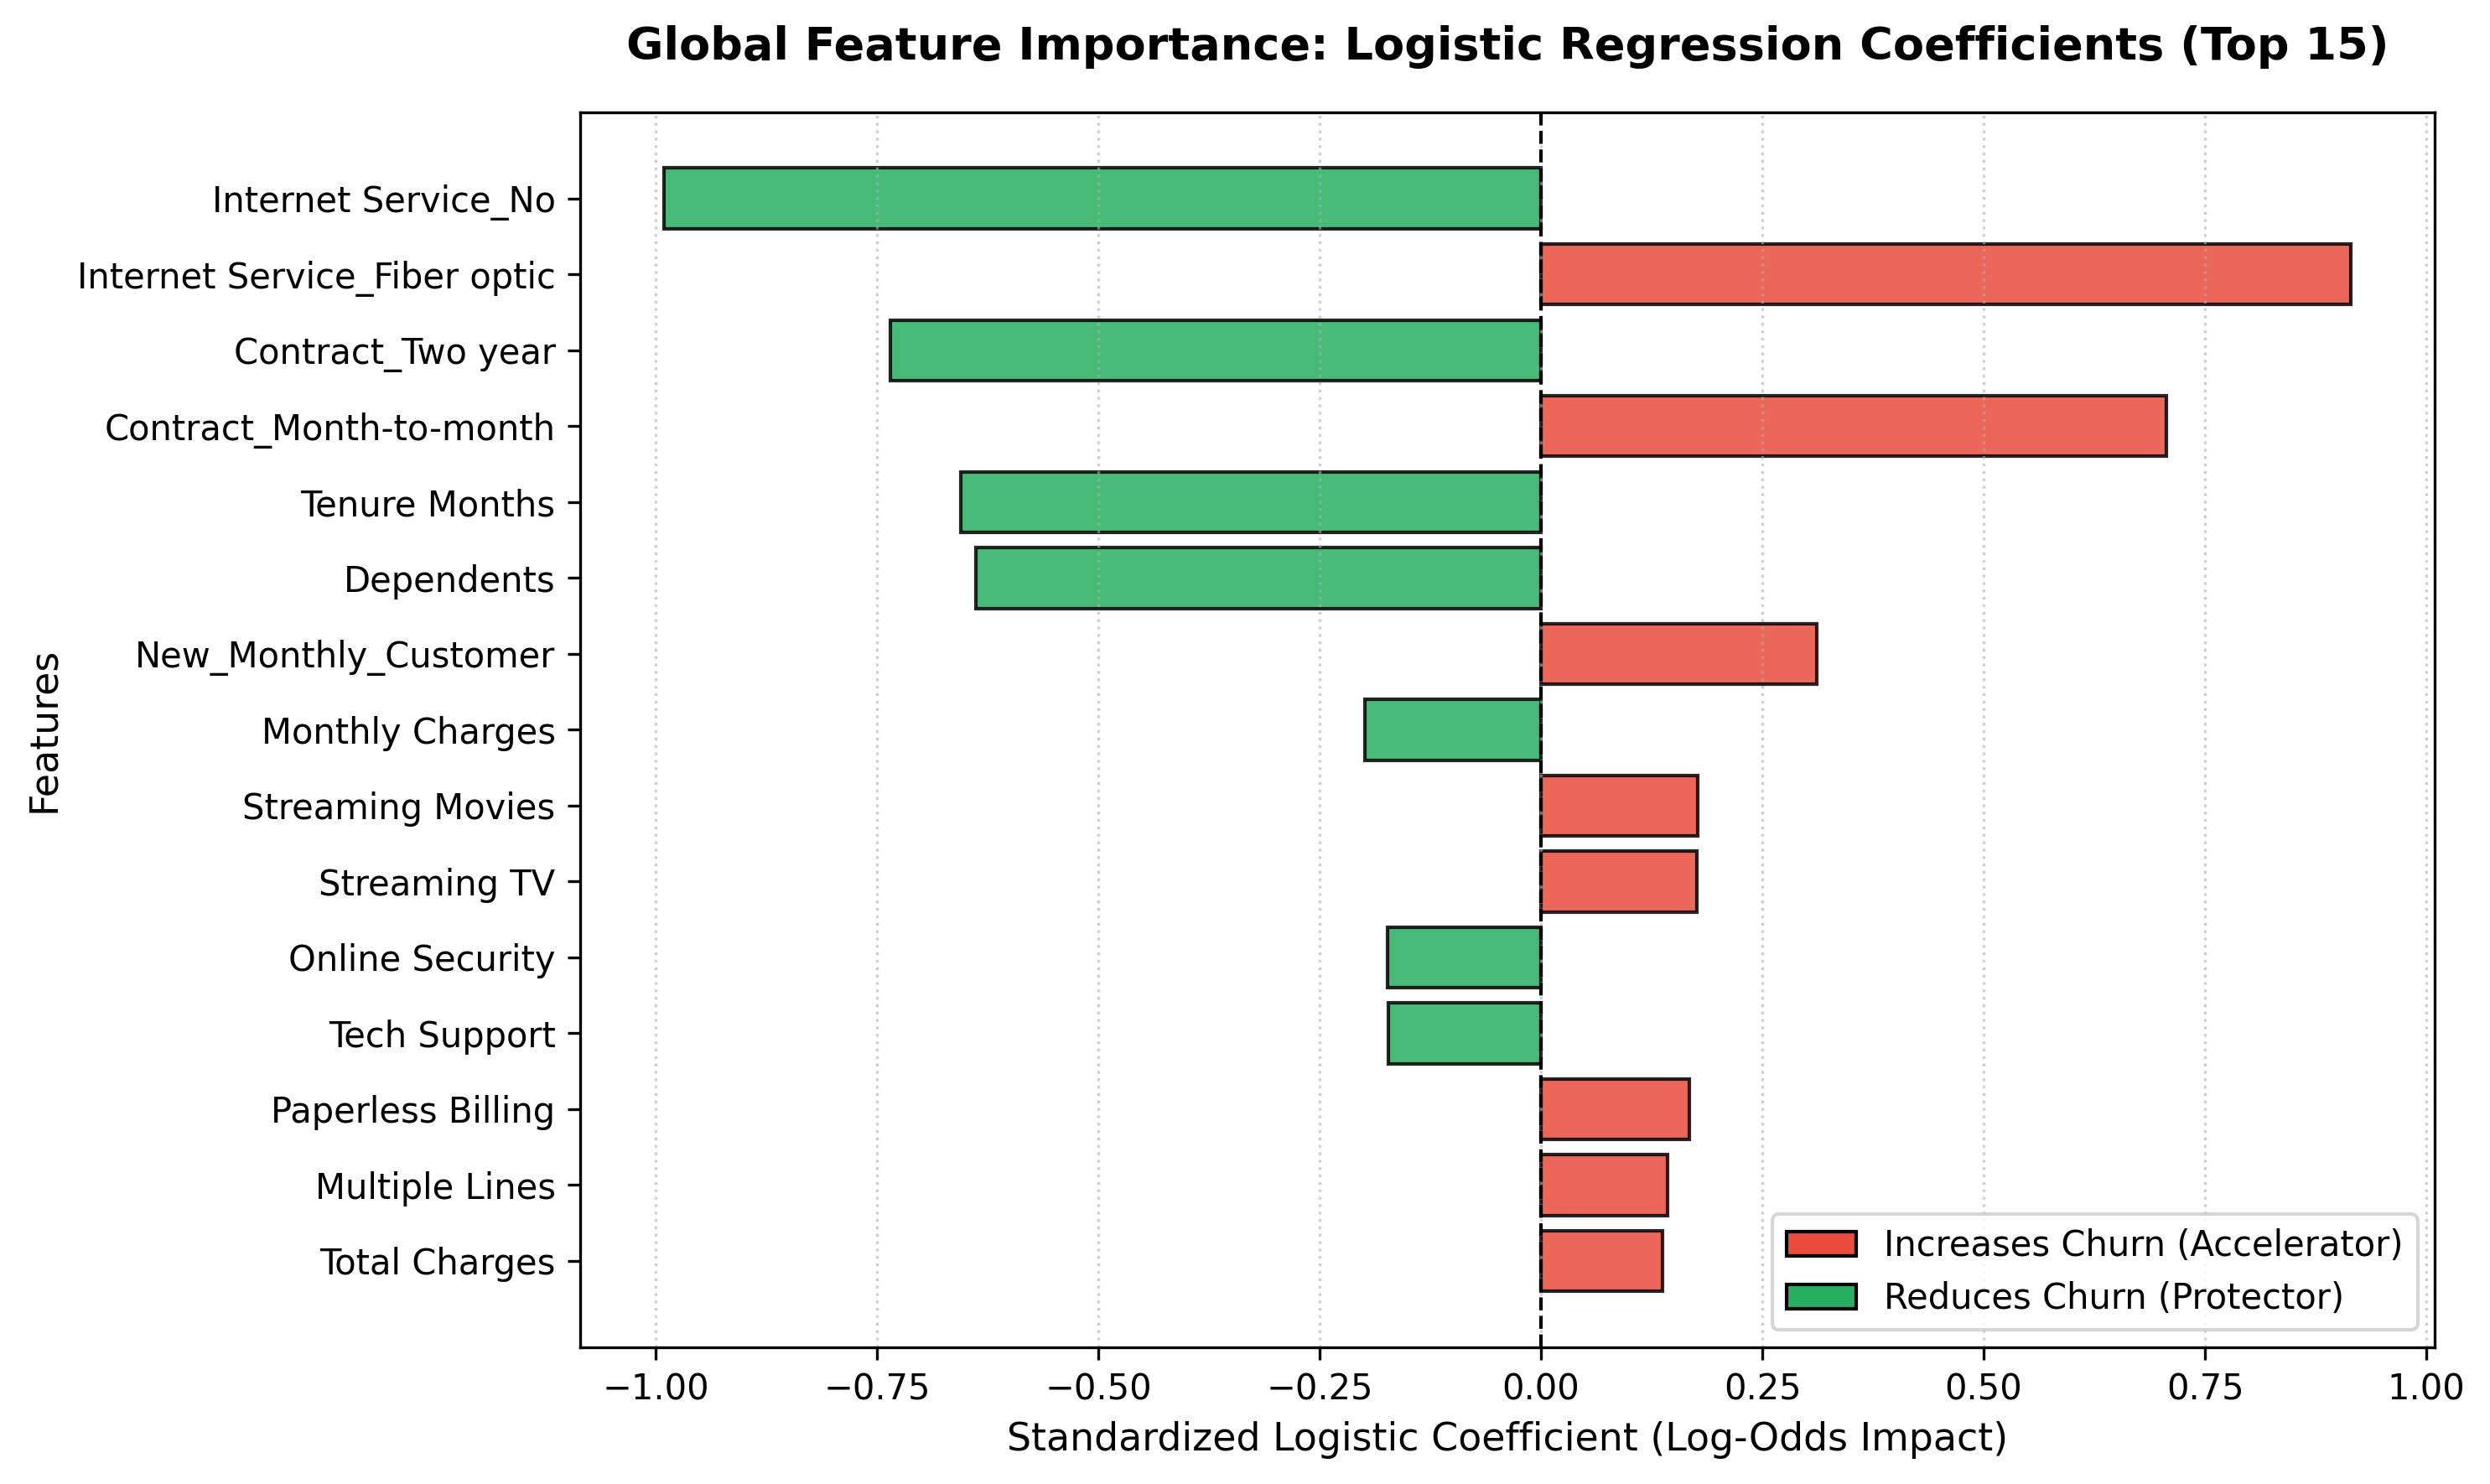

In [4]:
explainer.plot_feature_importance(top_n=15)

## 3. Global SHAP Analysis (Mean Absolute SHAP & Beeswarm)

In [5]:
df_shap_summary = explainer.compute_global_shap_summary(X)
print("Top 10 Features by Mean Absolute SHAP Impact:")
df_shap_summary.head(10)

Top 10 Features by Mean Absolute SHAP Impact:


,Feature,Mean_Abs_SHAP,Coefficient,Direction,SHAP_Rank
0,Tenure Months,0.583500,-0.655117,Reduces Churn,1
1,Dependents,0.537812,-0.638007,Reduces Churn,2
2,Internet Service_Fiber optic,0.450585,0.914521,Increases Churn,3
3,Contract_Month-to-month,0.349427,0.705968,Increases Churn,4
4,Internet Service_No,0.336149,-0.990285,Reduces Churn,5
5,New_Monthly_Customer,0.280649,0.311477,Increases Churn,6
6,Contract_Two year,0.268656,-0.735056,Reduces Churn,7
7,Monthly Charges,0.173199,-0.198733,Reduces Churn,8
8,Streaming Movies,0.172735,0.177247,Increases Churn,9
9,Streaming TV,0.171595,0.176378,Increases Churn,10


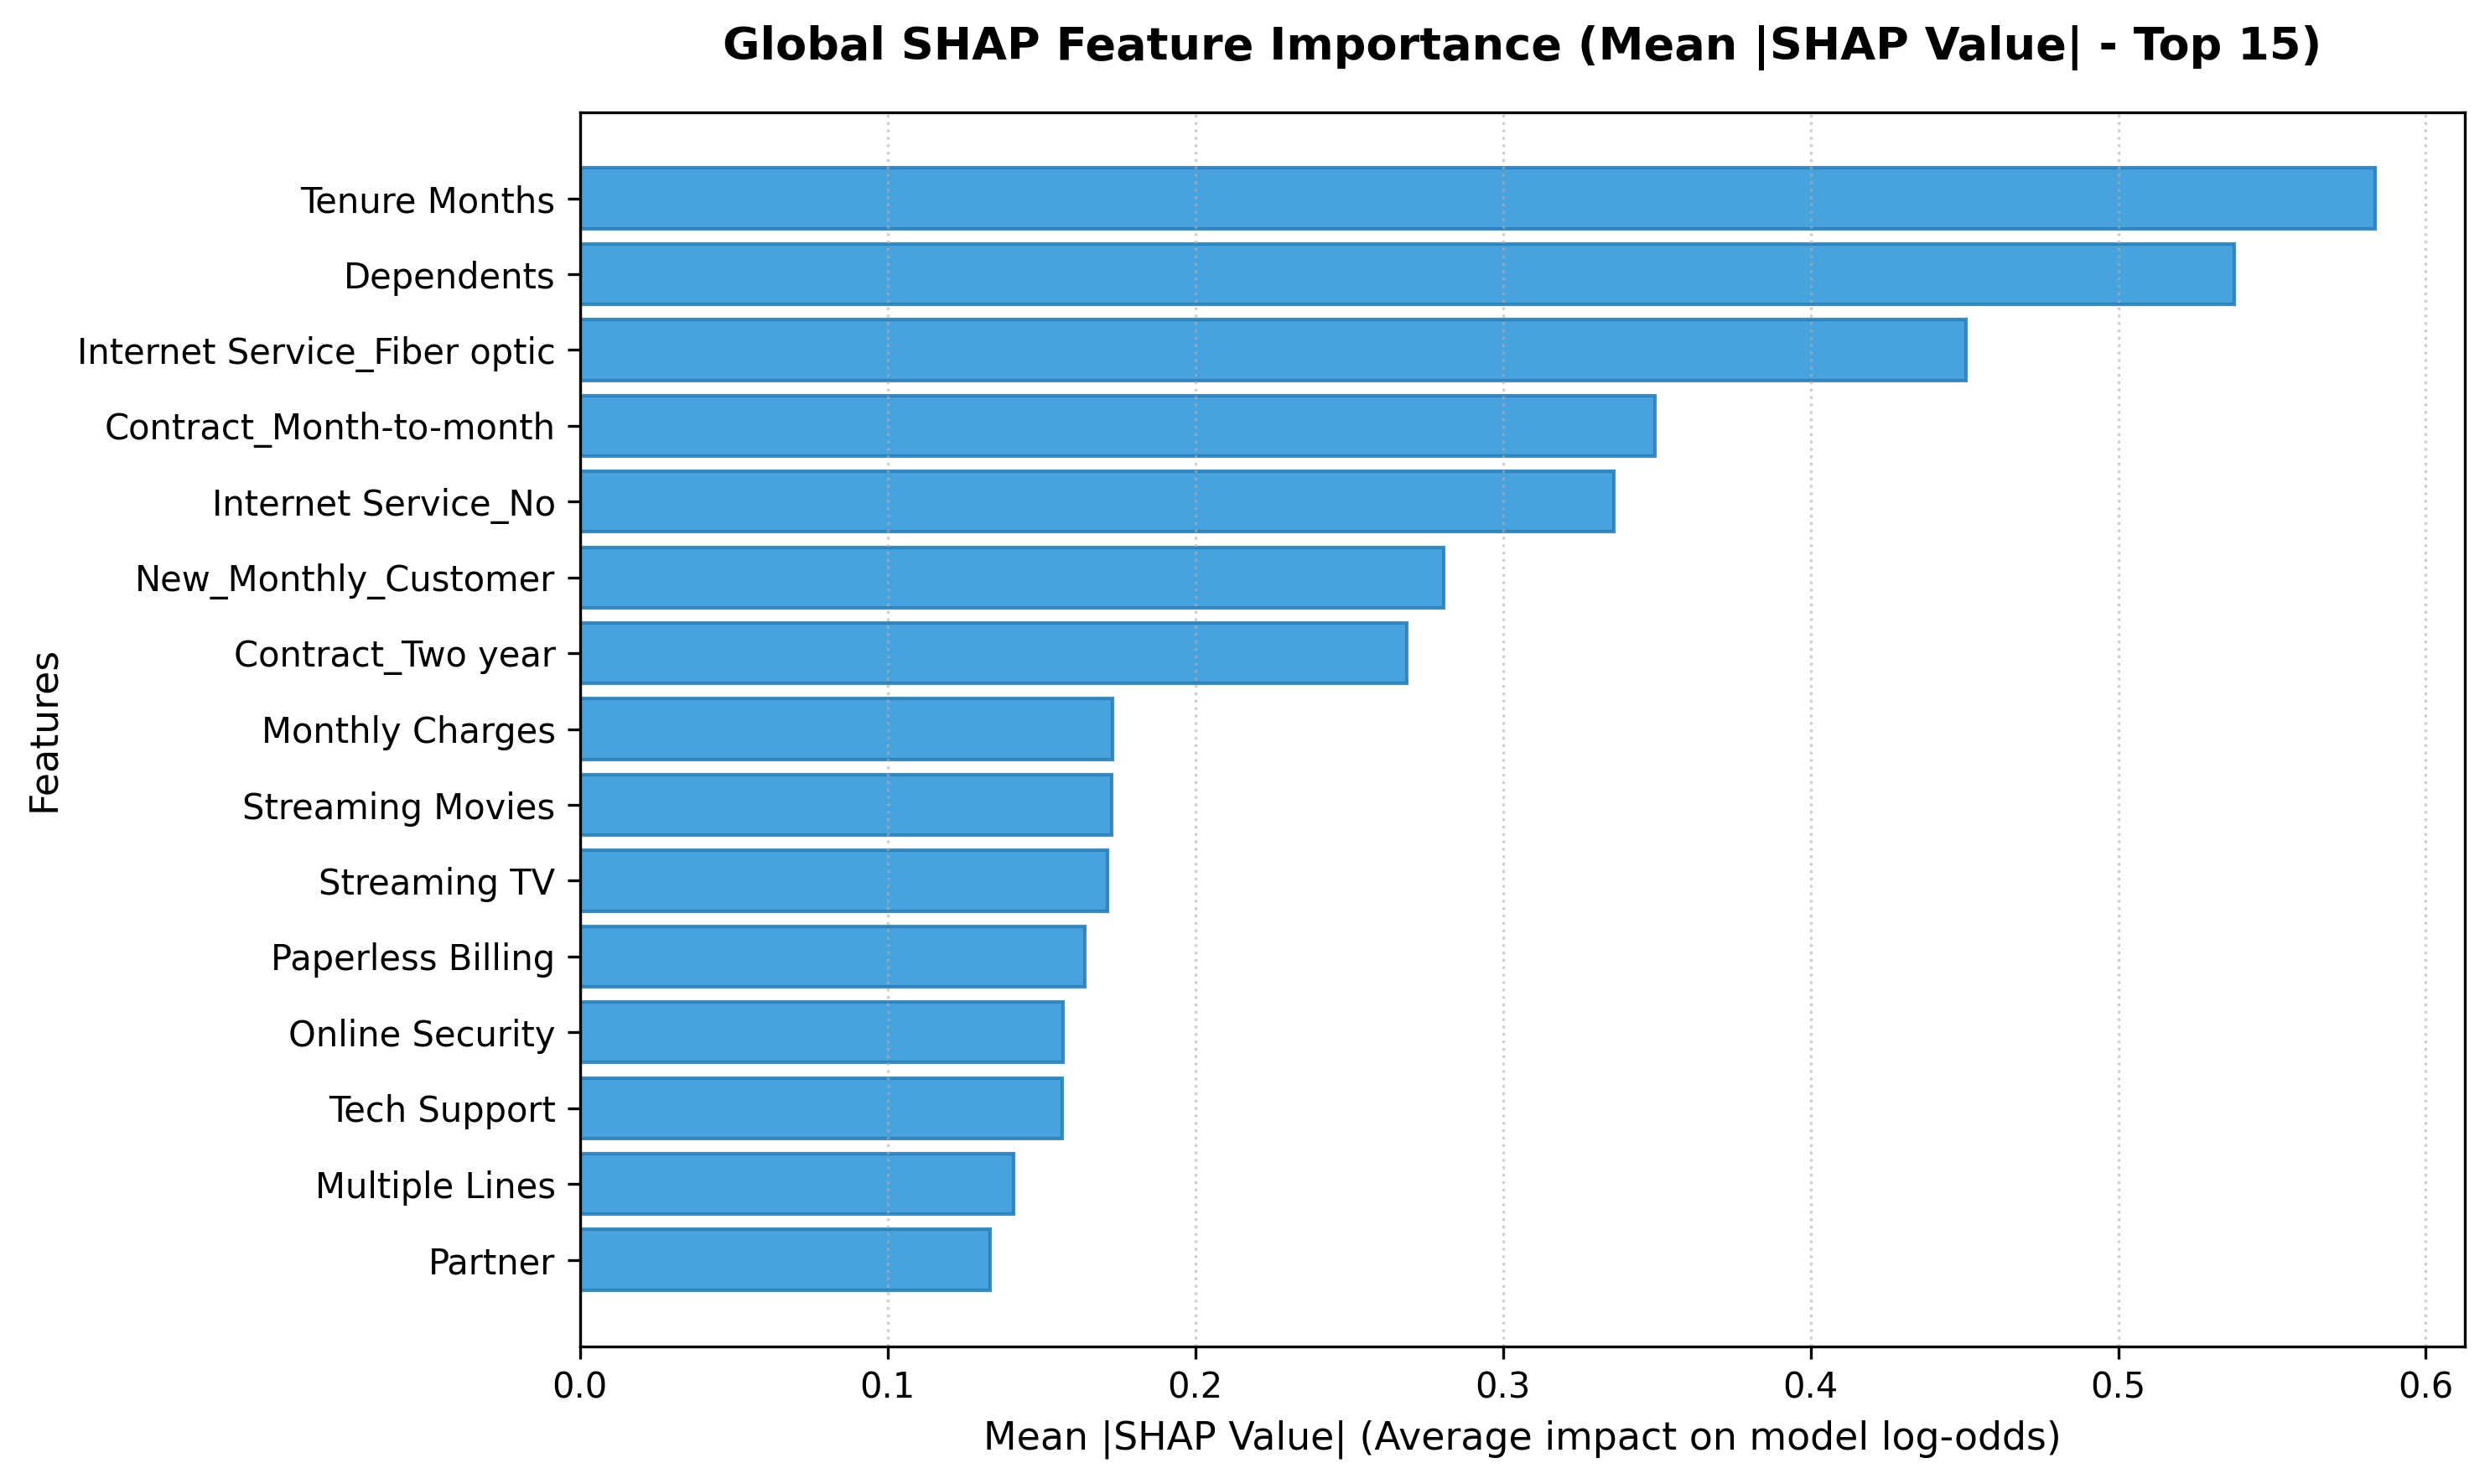

In [6]:
explainer.plot_shap_summary_bar(X, top_n=15)

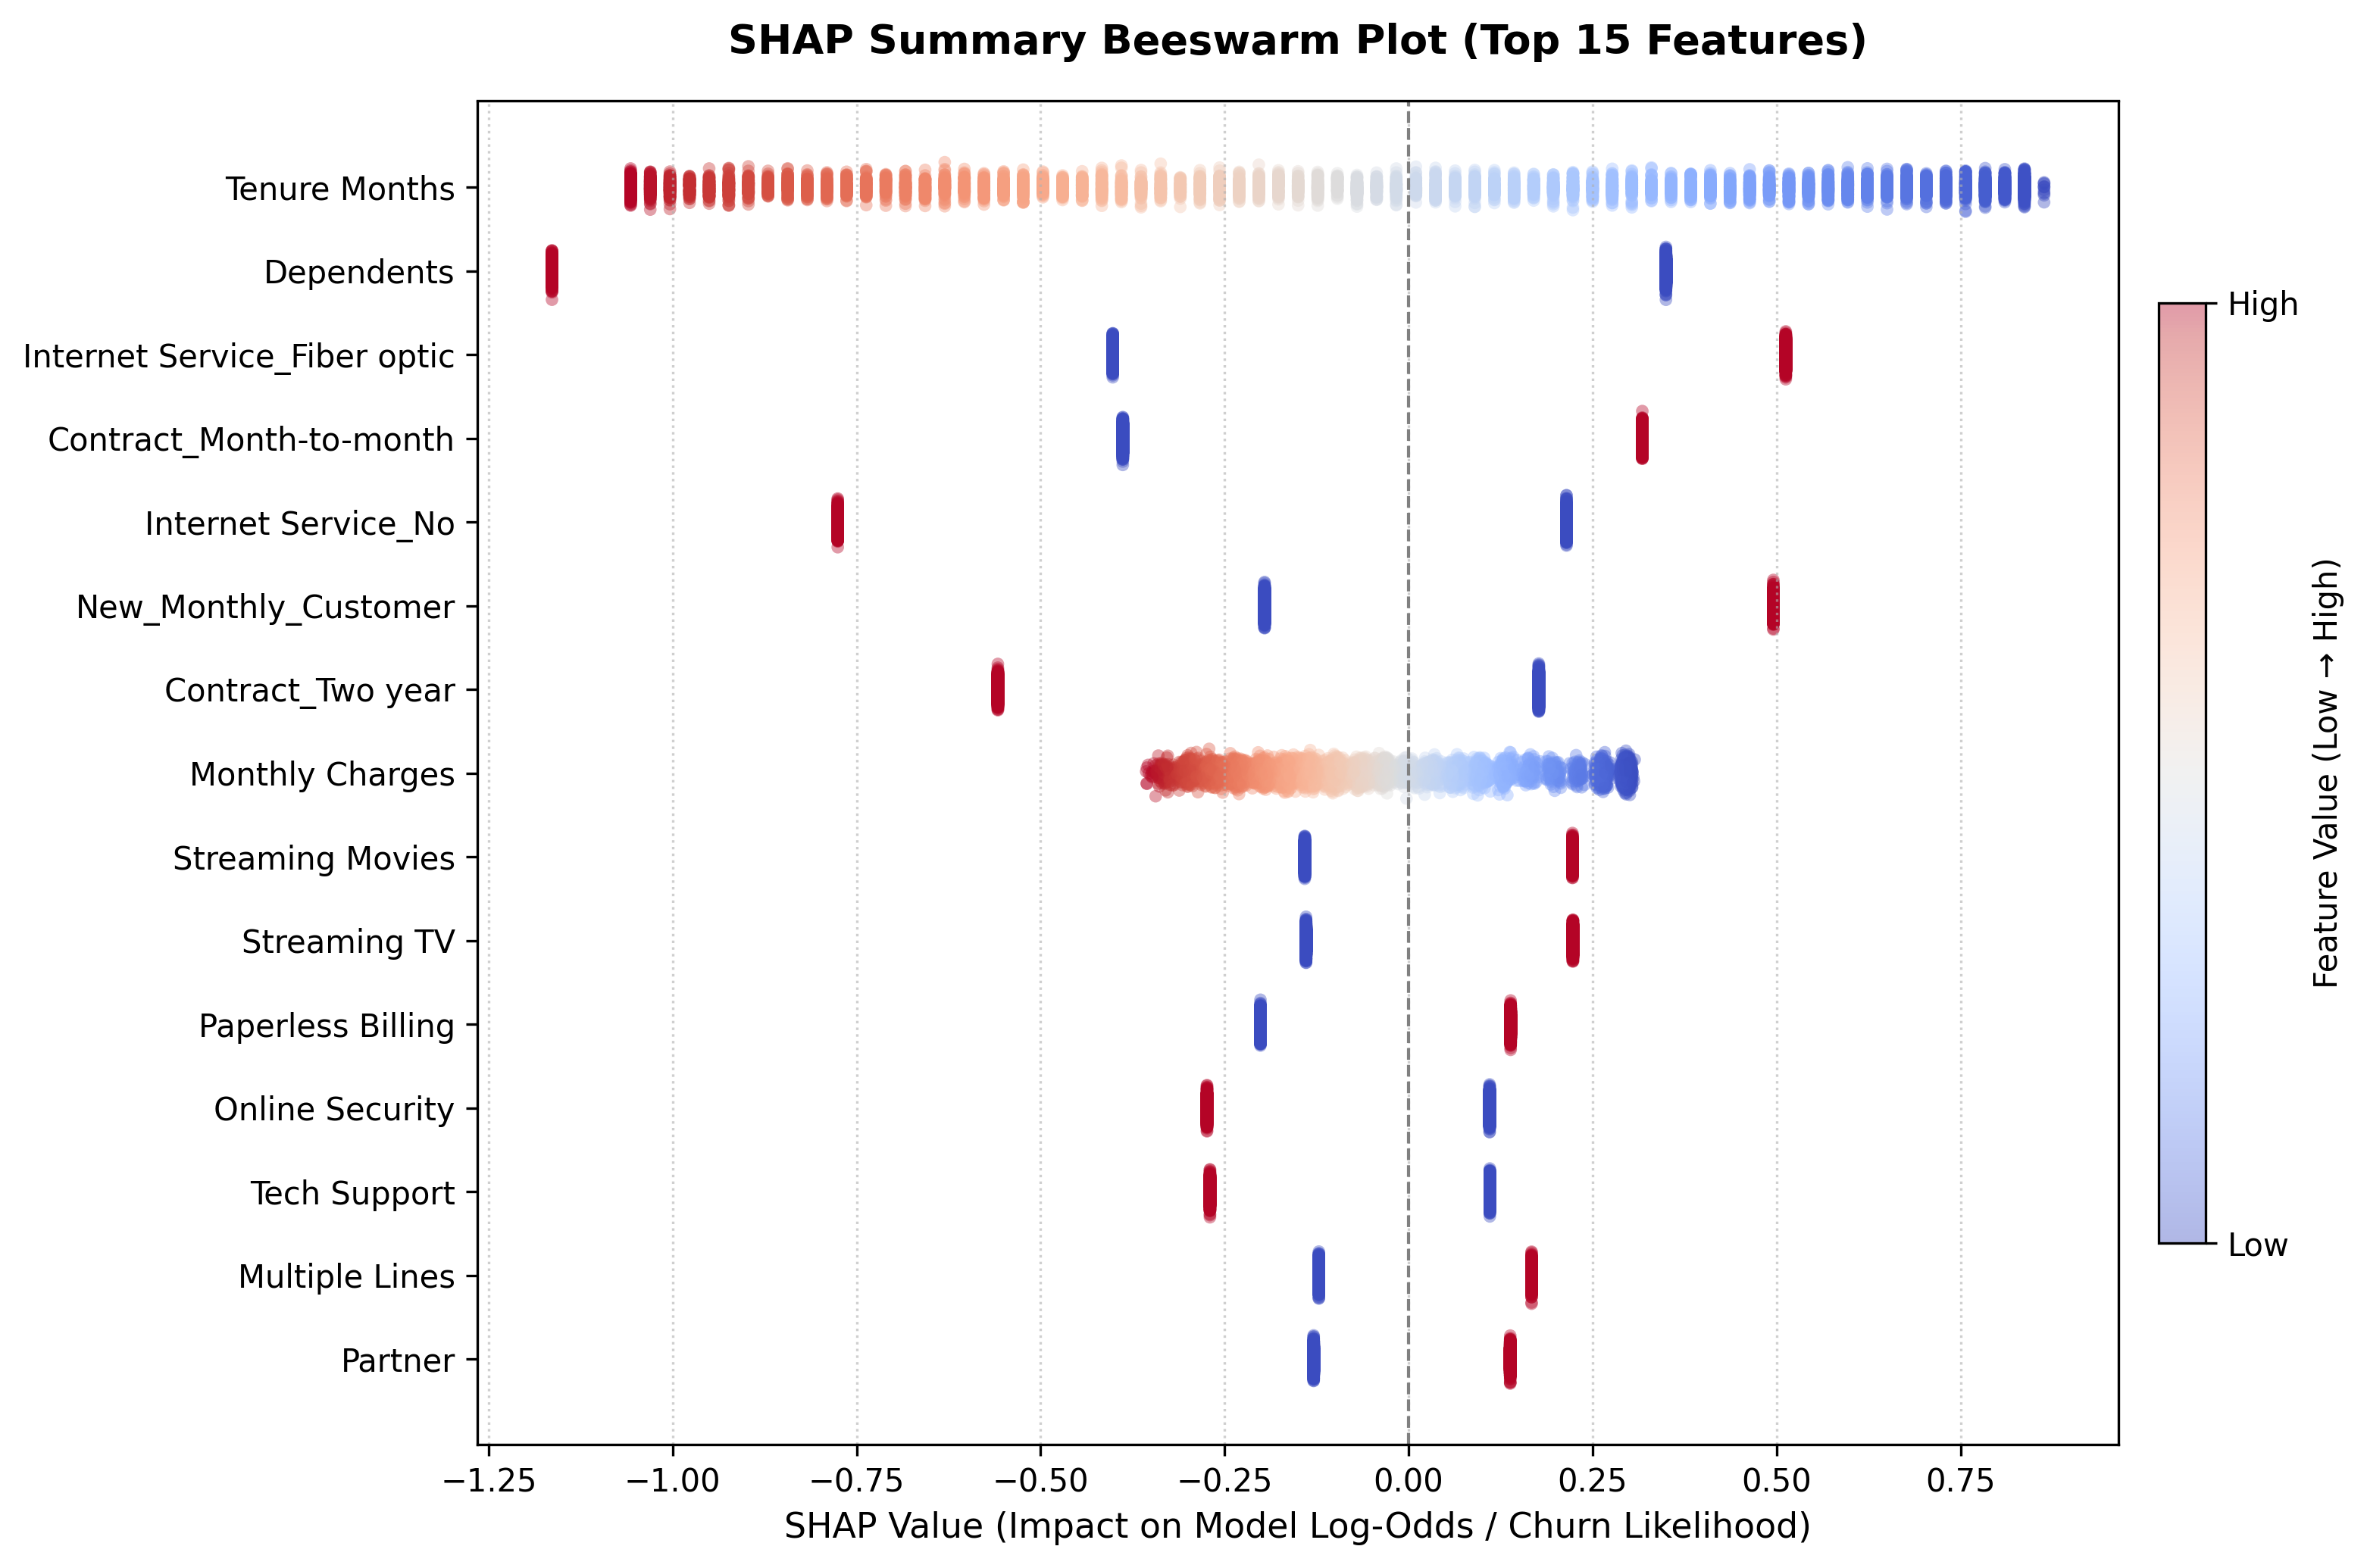

In [7]:
explainer.plot_shap_beeswarm(X, top_n=15)